朴素贝叶斯分类器的平均准确率：78.37%
LDA分类器的平均准确率：78.48%


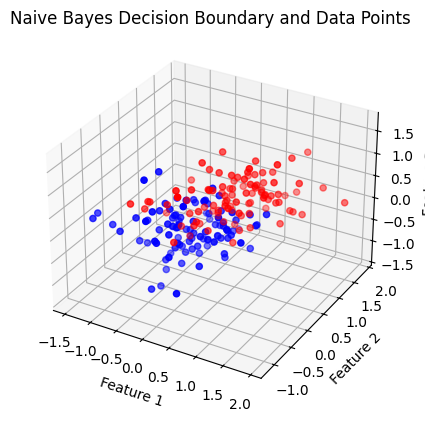

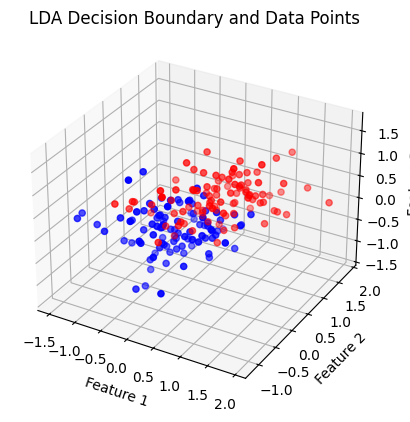

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

# 朴素贝叶斯分类器类定义
class NaiveBayesClassifier:
    def __init__(self):
        self.mu1, self.mu2 = None, None
        self.sigma1, self.sigma2 = None, None

    def fit(self, X1, X2):
        self.mu1 = np.mean(X1, axis=0)
        self.sigma1 = np.std(X1, axis=0)
        self.mu2 = np.mean(X2, axis=0)
        self.sigma2 = np.std(X2, axis=0)

    def predict(self, X):
        prob1 = np.prod([1 / (np.sqrt(2 * np.pi) * self.sigma1[i]) * np.exp(-0.5 * ((X[i] - self.mu1[i]) / self.sigma1[i]) ** 2) for i in range(len(X))])
        prob2 = np.prod([1 / (np.sqrt(2 * np.pi) * self.sigma2[i]) * np.exp(-0.5 * ((X[i] - self.mu2[i]) / self.sigma2[i]) ** 2) for i in range(len(X))])
        return 0 if prob1 > prob2 else 1

# 生成新的数据
np.random.seed(42)
mu1 = [0, 0, 0]
mu2 = [0.5, 0.5, 0.5]
cov = [[0.3, 0.1, 0.1], [0.1, 0.3, -0.1], [0.1, -0.1, 0.3]]

data1 = np.random.multivariate_normal(mu1, cov, 100)
data2 = np.random.multivariate_normal(mu2, cov, 100)
labels1 = np.zeros(data1.shape[0])
labels2 = np.ones(data2.shape[0])

# 合并数据和标签
data = np.concatenate((data1, data2), axis=0)
labels = np.concatenate((labels1, labels2), axis=0)

# 朴素贝叶斯分类器和LDA分类器的准确性存储
nb_accuracies = []
lda_accuracies = []

# 进行100次训练和测试
for step in range(100):
    # 随机分割数据集
    X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=step)
    
    # 根据标签分割训练数据
    X_train1 = X_train[y_train == 0]
    X_train2 = X_train[y_train == 1]

    # 实例化朴素贝叶斯分类器并训练
    nb_classifier = NaiveBayesClassifier()
    nb_classifier.fit(X_train1, X_train2)

    # 评估朴素贝叶斯分类器准确率
    nb_predictions = np.array([nb_classifier.predict(x) for x in X_test])
    nb_accuracy = np.mean(nb_predictions == y_test)
    nb_accuracies.append(nb_accuracy)

    # 实例化LDA分类器并训练
    lda_classifier = LinearDiscriminantAnalysis()
    lda_classifier.fit(X_train, y_train)

    # 评估LDA分类器准确率
    lda_predictions = lda_classifier.predict(X_test)
    lda_accuracy = np.mean(lda_predictions == y_test)
    lda_accuracies.append(lda_accuracy)

# 计算平均准确性
nb_mean_accuracy = np.mean(nb_accuracies) * 100
print(f"朴素贝叶斯分类器的平均准确率：{nb_mean_accuracy:.2f}%")

lda_mean_accuracy = np.mean(lda_accuracies) * 100
print(f"LDA分类器的平均准确率：{lda_mean_accuracy:.2f}%")

# 绘制最后一步朴素贝叶斯分类器的决策边界
x_min, x_max = -1, 1.5
y_min, y_max = -1, 1.5
z_min, z_max = -1, 1.5
xx, yy, zz = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50),
                         np.linspace(z_min, z_max, 50))
grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
nb_Z = np.array([nb_classifier.predict(point) for point in grid])
nb_Z = nb_Z.reshape(xx.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data1[:, 0], data1[:, 1], data1[:, 2], color='blue', label='Class 1')
ax.scatter(data2[:, 0], data2[:, 1], data2[:, 2], color='red', label='Class 2')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
plt.title('Naive Bayes Decision Boundary and Data Points')

plt.show()

# 绘制最后一步LDA分类器的决策边界
lda_Z = lda_classifier.predict(grid)
lda_Z = lda_Z.reshape(xx.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data1[:, 0], data1[:, 1], data1[:, 2], color='blue', label='Class 1')
ax.scatter(data2[:, 0], data2[:, 1], data2[:, 2], color='red', label='Class 2')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
plt.title('LDA Decision Boundary and Data Points')

plt.show()